# Synethtic to Real Inference Object Detection

### Install dependencies

In [ ]:
!pip install ultralytics comet_ml

### Create model training parameters file

In [ ]:
with open("yolo_params.yaml", "w") as f:
    f.write("""
# Dataset paths
train: /kaggle/input/falcon-object-detection/ObjectDetectionDataset/train/images  # Path to training images
val: /kaggle/input/falcon-object-detection/ObjectDetectionDataset/val/images      # Path to validation images
test: /kaggle/input/synthetic-2-real-object-detection-challenge/Synthetic to Real Object Detection Challenge/data/test    # Path to test images

# Class information
nc: 1                     # Number of classes
names: ['cheerios']       # Class names
""")

### Use CometML to visualize training

In [ ]:
import comet_ml
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
COMET_API_KEY = user_secrets.get_secret("COMET_API_KEY")

comet_ml.login(project_name="synthetic-to-real", api_key=COMET_API_KEY)

## Training

### Model: YOLOv11x
After prolonged experimentation with hyperparameters, I moved from the nano size (YOLOv11n) model to the extra large for the best accuracy. 

### Training Parameters
- Epochs: 100
  - early stopping with no improvement after 20 epochs (patience=20)
- Image Size: 640 (default)
  - most optimal for large model
- Batch Size: 16 (default)
  - can be larger to increase training speed
  - can be smaller to improve gradient estimation
- Optimizer: SGD
  - Best for generalization to test dataset
  - Slower convergence than other choices (Adam, RMSProp, adagrad, etc)
- Learning Rate (lr0): 1e-4
  - Fine-tuned to converge quickly but retain generalization
  - Too low = stuck in local minima
  - Too high = jumps over global minima
- Momentum: 0.975 (default = 0.937)
  - Fine-tuned to increase convergence rate, yet not oscillate or shoot past global minima
- Weight Decay: 1e-4 (default = 5e-4)
  - Decreased from default in order to avoid underfitting the model
- Cosine Learning Rate Scheduler (cos_lr)
  - Allowed the model to have a smooth convergence
- Dropout: 0.4
  - Turned off neurons during training to avoid overfitting
### Augmentation Parameters

This was a bunch of trial error, I tried out many different combinations including degrees, shear, perspective, and mixup. Nevertheless, changing those augmentation settings may have harmed the model's ability to infer on the testing set. 

Ultimately, I settled on the following augmentations
- Mosaic: p = 0.2 (default p = 1.0)
  - I found the model performing better when this augmentation was set a lower chance
  - Learn more about it [here](https://www.analyticsvidhya.com/blog/2023/12/mosaic-data-augmentation/)
- Flip Up & Down (flipud): p = 0.25 (default p = 0)
  - The test set contained some upside down cereal boxes
- Scale: 1.0 (default = 0.5)
  - The test set contained varying sizes (large, small) of cereal boxes

### Miscellaneous Parameters
- single_cls = True
  - Forces the model to predict one class only
- plots = True
  - saves helpful graphs in the output files
    - The area under the Precision vs. Recall graph measures mAP-50 (the main metric)
    - Visualizations of the training and validation batches
    - Visualizations of the validation predictions (with bounding boxes drawn)
- cache = True
  - increased model efficiency
  - may be better to set cache = "disk" to remain more deterministic

In [ ]:
from ultralytics import YOLO
# Load a model
model = YOLO("yolo11x.yaml")  # build a new model from YAML
model = YOLO("yolo11x.pt")  # load a pretrained model (recommended for training)
model = YOLO("yolo11x.yaml").load("yolo11x.pt")  # build from YAML and transfer weights

IMG_SIZE = 640
# Train the model
results = model.train(data="yolo_params.yaml", 
                      epochs=100,
                      imgsz=IMG_SIZE, 
                      patience=20,
                      cos_lr=True,
                      dropout=0.4, 
                      mosaic=0.2, 
                      lr0=0.0001, 
                      optimizer="SGD", 
                      momentum=0.975,
                      weight_decay=0.0001,
                      single_cls=True, 
                      plots=True,
                      cache=True,
                      flipud=0.25,
                      scale=1.0
                     )

## Results
### Comparing models (x, m, n) by mAP-50, mAP-95, Precision, Recall
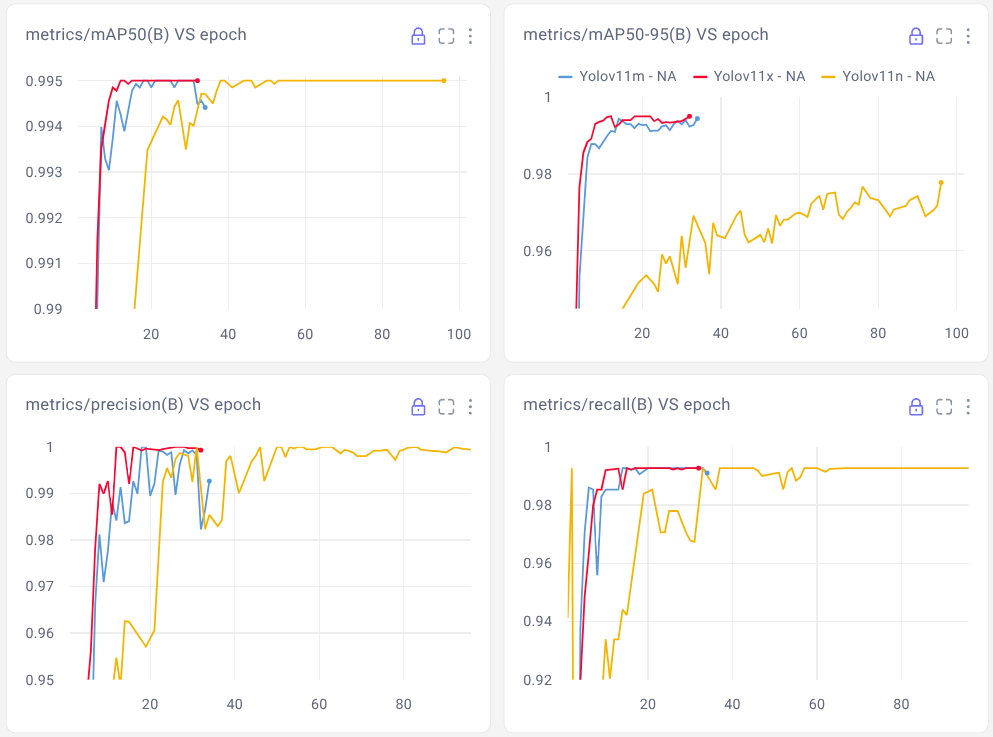
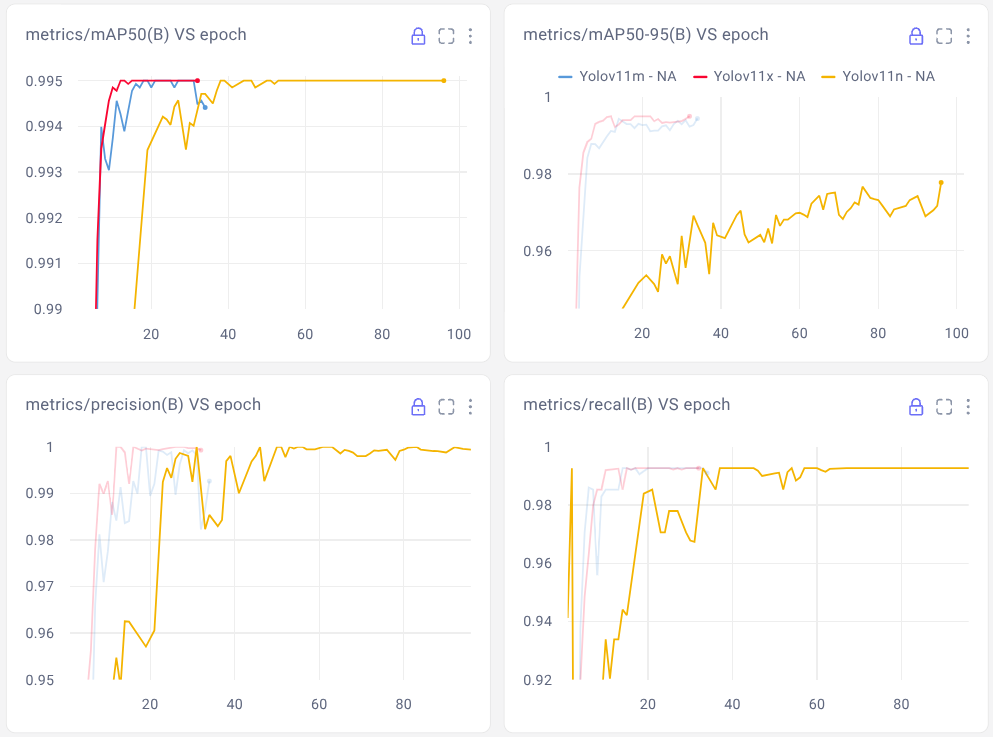

## Understanding mAP-50

### Definitions
- **mAP-50**: Mean Average Precision at an intersection over union (IoU) threshold of 0.50
- **Precision**: tp = true positives, fp = false positives $$precision = \frac{tp}{tp + fp}$$
- **Recall**: fn = false negatives $$recall = \frac{tp}{tp+fn}$$
- **Precision-Recall Curve**
  - While using the model to predict, the confidence threshold (minimum confidence to accept prediction) is iteratively decreased. As the confidence threshold decreases, the number of false negatives thus decreases, which means the **recall** increases. For each confidence threshold, you can also calculate the **precision**. Thus, a curve can be created relating recall to precision.
  - Here is an example from our trained YOLOv11x model:
    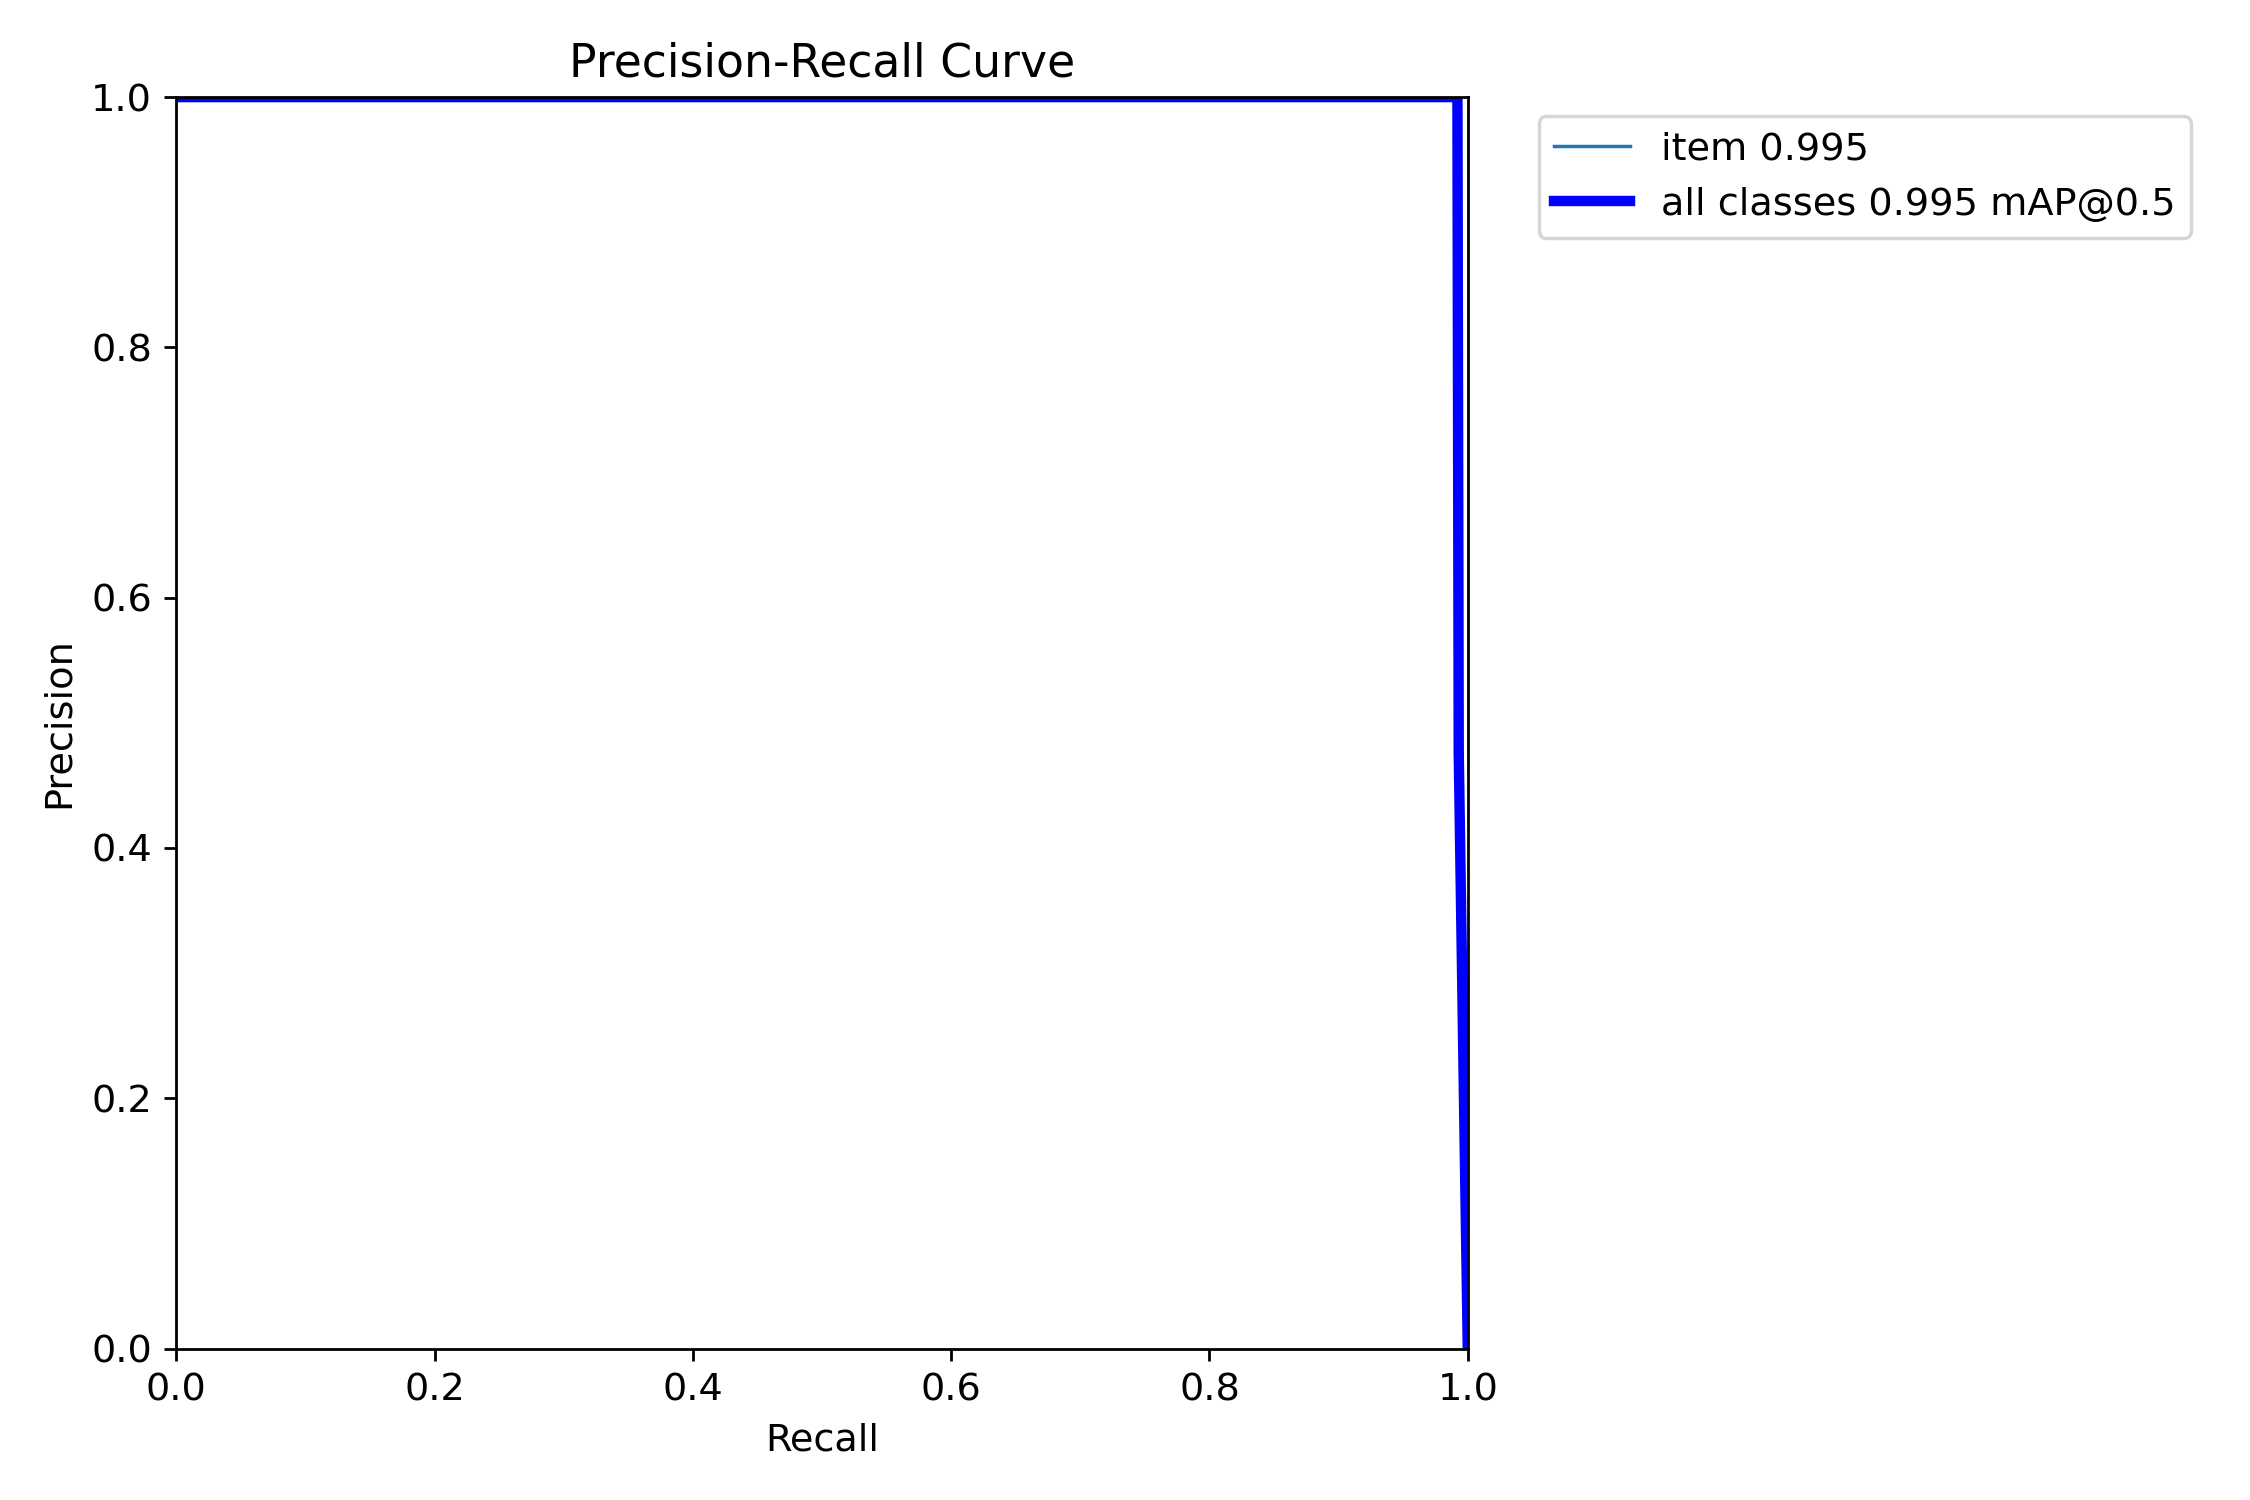
- **Mean Average Precision**: This is calculated as the area under the **Precision-Recall Curve**.
- **IoU**: The percentage of the true bounding box that must be covered by the predicted bounding box to be considered a true positive.

Therefore, **mAP-50** calculates the area under the **Precision-Recall Curve** given that the predicted bounding boxes cover at least 50% of the true bounding box. 

### Maximizing mAP-50
Since the **mAP-50** is essentially the area under the **Precision-Recall Curve**, then we must maximize this area. The most effective method to do so is to increase the range of **recall** values so that there is more area available under the curve at the highest of **recall** values. Recall (no pun intended), that the **Precision-Recall Curve** is created as the confidence threshold is iterated through. Therefore, our submission file must include the low confidence predictions, to ensure that even at a low confidence threshold, false negatives are included so that the resulting area from high **recall** values are aggregated. 

In [ ]:
results = model.predict("/kaggle/input/synthetic-2-real-object-detection-challenge/Synthetic to Real Object Detection Challenge/data/test/images",
                       #iou=0.2,
                       imgsz=IMG_SIZE,
                       save=True,
                       #show_labels=False,
                       conf=0.001,
                       #max_det=1,
                       #visualize=True,
                       #max_det=2,
                       verbose=False
                       )

Visualize bounding box predictions on testing data in runs/detect/train2

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import cv2
import os
import yaml


# Function to predict and save images
def predict_and_save(model, image_path, output_path_txt):
    """
    Predict bounding boxes for an image and save them in YOLO format.
    
    Args:
        model: YOLOv8 model.
        image_path: Path to the input image.
        output_path_txt: Path to save the predictions.
    """

    # Perform prediction
    results = model.predict(image_path,
                            imgsz=IMG_SIZE,
                            conf=0.001)
    result = results[0]
    img_height, img_width = result.orig_shape

    # Save bounding boxes in YOLO format
    with open(output_path_txt, 'w') as f:
        for box in result.boxes:
            cls_id = int(box.cls)
            conf = box.conf.item()  
            # print(box.xywh[0][0].item(), box.xywh[0][1].item())
            x_center = box.xywh[0][0].item() / img_width
            y_center = box.xywh[0][1].item() / img_height
            # print(x_center, y_center)
            width = box.xywh[0][2].item() / img_width
            height = box.xywh[0][3].item() / img_height
            f.write(f"{cls_id} {conf} {x_center} {y_center} {width} {height}\n")

def main():
    # Set working directory
    __file__ = "/kaggle/input/synthetic-2-real-object-detection-challenge/Synthetic to Real Object Detection Challenge/predict.py"
    this_dir = Path(__file__).parent
    working_dir = Path("/kaggle/working/")
    os.chdir(this_dir)

    # Load test path from YAML
    with open(this_dir / 'yolo_params.yaml', 'r') as file:
        data = yaml.safe_load(file)
        if 'test' not in data or not data['test']:
            print("Add 'test: path/to/test/images' to yolo_params.yaml")
            exit()
        images_dir = Path(data['test'])
    
    # Validate test directory
    if not images_dir.exists():
        print(f"Test directory {images_dir} does not exist")
        exit()
    if not any(images_dir.glob('*')):
        print(f"Test directory {images_dir} is empty")
        exit()

    # Load the latest trained YOLO model
    detect_path = working_dir / "runs" / "detect"
    train_folders = [f for f in os.listdir(detect_path) if os.path.isdir(detect_path / f) and f.startswith("train")]
    if len(train_folders) == 0:
        raise ValueError("No training folders found")
    idx = 0
    """if len(train_folders) > 1:
        choice = -1
        choices = list(range(len(train_folders)))
        while choice not in choices:
            print("Select the training folder:")
            for i, folder in enumerate(train_folders):
                print(f"{i}: {folder}")
            choice = input()
            if not choice.isdigit():
                choice = -1
            else:
                choice = int(choice)
        idx = choice"""

    model_path = detect_path / train_folders[idx] / "weights" / "best.pt"
    model = YOLO(model_path)

    # Directory with images to generate predictions
    output_dir = working_dir / "predictions" # Replace with the directory where you want to save predictions
    output_dir.mkdir(parents=True, exist_ok=True)

    # Create labels subdirectories
    labels_output_dir = output_dir / 'labels'
    
    # images_output_dir.mkdir(parents=True, exist_ok=True)
    labels_output_dir.mkdir(parents=True, exist_ok=True)

    # Iterate through the images in the directory
    for img_path in images_dir.glob('*'):
        if img_path.suffix not in ['.png', '.jpg','.jpeg']:
            continue
        output_path_txt = labels_output_dir / img_path.with_suffix('.txt').name  # Save label in 'labels' folder
        predict_and_save(model, img_path, output_path_txt)

    print(f"Bounding box labels saved in {labels_output_dir}")
    data = this_dir / 'yolo_params.yaml'
    print(f"Model parameters saved in {data}")

if __name__ == '__main__':
    main()


In [ ]:
from pathlib import Path
import pandas as pd
import csv
import sys

def predictions_to_csv(
    preds_folder: str = "predictions/labels", 
    output_csv: str = "submission.csv", 
    test_images_folder: str = "data/test/images",
    allowed_extensions: tuple = (".jpg", ".png", ".jpeg")
):
    """
    Convert YOLO prediction files to Kaggle submission CSV format
    with strict validation.
    """
    # Validate inno boxputs
    preds_path = Path(preds_folder)
    if not preds_path.exists():
        print(f"ERROR: Prediction folder '{preds_folder}' does not exist")
        sys.exit(1)

    # Get test image IDs (without extensions)
    test_images_path = Path(test_images_folder)
    if not test_images_path.exists():
        print(f"ERROR: Test images folder '{test_images_folder}' not found")
        sys.exit(1)
        
    test_images = {
        p.stem: True 
        for p in test_images_path.glob("*") 
        if p.suffix.lower() in allowed_extensions
    }
    print(f"Found {len(test_images)} test images")

    # Collect predictions with validation
    predictions = []
    error_count = 0
    bboxes = 0
    
    for txt_file in preds_path.glob("*.txt"):
        image_id = txt_file.stem
        
        # Validate image_id
        if image_id not in test_images:
            print(f"Skipping non-test image prediction: {txt_file.name}")
            continue
            
        with open(txt_file, "r") as f:
            valid_lines = []
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue  # Skip empty lines
                    
                parts = line.split()
                # Validate YOLO format: 6 values per line
                if len(parts) != 6:
                    print(f"Invalid prediction in {txt_file.name} line {line_num}: {line}")
                    error_count += 1
                    continue
                    
                try:
                    # Validate numerical values
                    [float(x) for x in parts]
                    valid_lines.append(line)
                    bboxes += 1
                except ValueError:
                    print(f"Non-numeric values in {txt_file.name} line {line_num}: {line}")
                    error_count += 1
                    continue

        pred_str = " ".join(valid_lines) if valid_lines else "no box"
        predictions.append({"image_id": image_id, "prediction_string": pred_str})

    # Create submission dataframe
    submission_df = pd.DataFrame({"image_id": list(test_images.keys())})
    
    if predictions:
        preds_df = pd.DataFrame(predictions)
        final_df = submission_df.merge(preds_df, on="image_id", how="left").fillna("no boxes")
    else:
        final_df = submission_df
        final_df["prediction_string"] = "no boxes"

    # Save with CSV quoting rules
    final_df.to_csv(output_csv, index=False, quoting=csv.QUOTE_NONNUMERIC)
    
    print(f"\n Success! Submission saved to {output_csv}")
    print(f"   Total predictions: {len(predictions)}")
    print(f"   Total bounding boxes: {bboxes}")
    print(f"   Validation errors: {error_count}")

if __name__ == "__main__":

    predictions_to_csv(
        preds_folder="/kaggle/working/predictions/labels",
        output_csv="/kaggle/working/submission.csv",
        test_images_folder="/kaggle/input/synthetic-2-real-object-detection-challenge/Synthetic to Real Object Detection Challenge/data/test/images"
    )


In [ ]:
!zip -r /kaggle/working/train.zip /kaggle/working/runs/detect/train

In [ ]:
!zip -r /kaggle/working/predictions.zip /kaggle/working/runs/detect/train2